In [1]:
import h5py
import numpy as np

def load_and_prepare(path, pilot_syms, p_spacing):
    # 1) load & squeeze
    with h5py.File(path, "r") as f:
        x = np.squeeze(f["x"][...])   # → (N, 14, 612)
        y = np.squeeze(f["y"][...])   # → (N, 14, 612)
        h = np.squeeze(f["h"][...])   # → (N, 14, 612)

    # sanity
    assert x.shape == y.shape == h.shape
    N, Ns, Nsc = x.shape

    # 2) LS estimate at pilots
    H_ls = y / x
    pilot_subcs = np.arange(0, Nsc, p_spacing)  # e.g. [0,4,8,…]

    # pick out just the pilots: (N, len(pilot_syms), len(pilot_subcs))
    H_ls_p = H_ls[:, pilot_syms, :][:, :, pilot_subcs]

    # 3) interpolate back to every subcarrier
    all_subcs = np.arange(Nsc)
    H_interp = np.zeros_like(H_ls)  # complex64

    for n in range(N):
        for si, sym in enumerate(pilot_syms):
            # real part
            real_vals = H_ls_p[n, si, :].real
            H_interp[n, sym, :].real = np.interp(all_subcs, pilot_subcs, real_vals)
            # imag part
            imag_vals = H_ls_p[n, si, :].imag
            H_interp[n, sym, :].imag = np.interp(all_subcs, pilot_subcs, imag_vals)

        # (optional) to fill non-pilot OFDM-symbol rows as well,
        # you'd do a 2D interpolation over (symbol, subcarrier) here.

    # 4) stack into real/imag channels
    inputs = np.stack([H_interp.real, H_interp.imag], axis=-1)  # (N,14,612,2)
    labels = np.stack([h.real,        h.imag],        axis=-1)  # (N,14,612,2)

    return inputs, labels


In [6]:
pilot_syms = [3, 10]
p_spacing  = 4
inputs, labels = load_and_prepare("data_snr15.hdf5", pilot_syms, p_spacing)

In [7]:
print(f"inputs mean:  {inputs.mean():.6e}")
print(f"inputs std:   {inputs.std():.6e}")
print(f"labels mean:  {labels.mean():.6e}")
print(f"labels std:   {labels.std():.6e}")

inputs mean:  7.610566e-05
inputs std:   2.675870e-01
labels mean:  5.231963e-04
labels std:   7.071070e-01


In [5]:
print(f"inputs mean:  {inputs.mean():.6e}")
print(f"inputs std:   {inputs.std():.6e}")
print(f"labels mean:  {labels.mean():.6e}")
print(f"labels std:   {labels.std():.6e}")

inputs mean:  4.616916e-06
inputs std:   2.656181e-01
labels mean:  1.056763e-05
labels std:   7.071057e-01


In [2]:
import os
import glob
import h5py
import numpy as np

EPS = 1e-8


def _robust_ls(y, x, eps=EPS):
    """
    Robust LS: y/x computed as y * conj(x) / (|x|^2 + eps)
    Shapes: (N, Ns, Nsc) complex
    """
    num = y * np.conj(x)
    den = (x.real * x.real + x.imag * x.imag) + eps
    return num / den

def load_and_prepare(path, pilot_syms, p_spacing, umi_interp=True):
    """
    path       : str, path to your .h5 (or .mat) file with datasets "x","y","h"
    pilot_syms : list or 1D array of symbol indices where pilots live (time axis)
    p_spacing  : int, spacing between pilot subcarriers (frequency axis)
    umi_interp : bool, if True do 2-D pilot interpolation; else return raw LS

    returns:
      inputs  : np.array, shape (N, Ns, Nsc, 2) real/imag of estimated H (input to models)
      labels  : np.array, shape (N, Ns, Nsc, 2) real/imag of true h (ground truth)
    """
    # --- load raw x, y, true h
    with h5py.File(path, "r") as f:
        # Expect complex datasets stored as complex dtype; if split, adjust here
        x = np.squeeze(f["x"][...])    # (N, Ns, Nsc) complex
        y = np.squeeze(f["y"][...])    # (N, Ns, Nsc) complex
        h = np.squeeze(f["h"][...])    # (N, Ns, Nsc) complex

    # --- LS estimate at every TF point (robust)
    H_ls = _robust_ls(y, x)            # (N, Ns, Nsc) complex
    N, Ns, Nsc = H_ls.shape

    if not umi_interp:
        # No interpolation: inputs are just raw LS everywhere
        inputs = np.stack([H_ls.real, H_ls.imag], axis=-1)     # (N, Ns, Nsc, 2)
        labels = np.stack([h.real,   h.imag],   axis=-1)       # (N, Ns, Nsc, 2)
        return inputs, labels

    # ---------- Interpolation path (UMi pilot interpolation in freq then time) ----------
    # Validate/clip pilot indices
    pilot_syms = np.asarray(pilot_syms, dtype=int)
    pilot_syms = pilot_syms[(pilot_syms >= 0) & (pilot_syms < Ns)]
    if pilot_syms.size == 0:
        raise ValueError("pilot_syms empty after clipping to [0, Ns). Provide valid pilot symbols.")
    if p_spacing is None or p_spacing <= 0:
        raise ValueError("p_spacing must be a positive integer for interpolation.")

    pilot_subcs = np.arange(0, Nsc, int(p_spacing))
    if pilot_subcs.size < 2:
        # Need at least two pilot tones for np.interp to work meaningfully
        raise ValueError("Not enough pilot subcarriers; increase p_spacing density (smaller spacing).")

    H_hat = np.zeros((N, Ns, Nsc), dtype=complex)

    # 1) frequency-axis interpolation at each pilot symbol
    all_subs = np.arange(Nsc)
    for n in range(N):
        for sym in pilot_syms:
            Hp = H_ls[n, sym, pilot_subcs]     # (P,) complex
            re = np.interp(all_subs, pilot_subcs, Hp.real)
            im = np.interp(all_subs, pilot_subcs, Hp.imag)
            H_hat[n, sym, :] = re + 1j * im

    # 2) time-axis interpolation at each subcarrier using values at pilot symbols
    all_syms = np.arange(Ns)
    for n in range(N):
        for k in range(Nsc):
            Hp = H_hat[n, pilot_syms, k]       # (K,) complex at pilot symbols
            re = np.interp(all_syms, pilot_syms, Hp.real)
            im = np.interp(all_syms, pilot_syms, Hp.imag)
            H_hat[n, :, k] = re + 1j * im

    inputs = np.stack([H_hat.real, H_hat.imag], axis=-1)       # (N, Ns, Nsc, 2)
    labels = np.stack([h.real,     h.imag],     axis=-1)       # (N, Ns, Nsc, 2)
    return inputs, labels

In [3]:
pilot_syms = [3, 10]
p_spacing  = 4
inputs, labels = load_and_prepare("data_snr15.hdf5", pilot_syms, p_spacing, umi_interp=True)

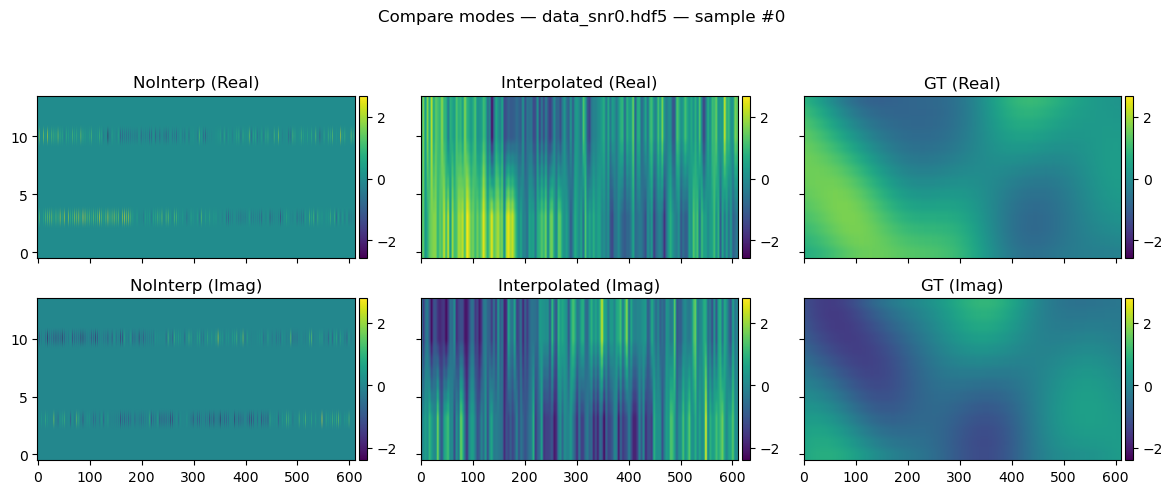

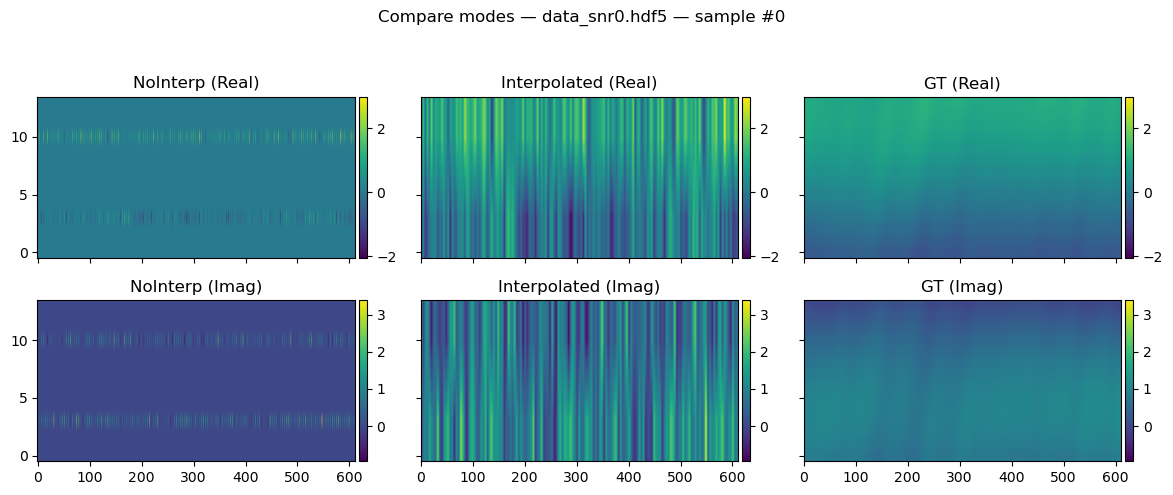

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _load_dicts(base_dir):
    data = np.load(os.path.join(base_dir, "channel_data_dict.npy"),  allow_pickle=True).item()
    gt   = np.load(os.path.join(base_dir, "channel_label_dict.npy"), allow_pickle=True).item()
    return data, gt

def _pick_key(dct, key_substr=None):
    keys = sorted(dct.keys())
    if key_substr is None:
        return keys[0]
    for k in keys:
        if key_substr in k:
            return k
    raise KeyError(f"No key containing '{key_substr}'. Available: {keys[:5]}... (+{len(keys)-5} more)")

def plot_single_mode(mode_dir, key_substr=None, idx=0, save_path=None, title_prefix=None):
    """
    mode_dir: path containing channel_data_dict.npy & channel_label_dict.npy
    key_substr: optional substring to choose a specific 'data_snrXX.hdf5' key
    idx: sample index to plot
    """
    data, gt = _load_dicts(mode_dir)
    key = _pick_key(data, key_substr)
    est = data[key]  # (N, Nsc, Ns, 2)
    lab = gt[key]    # (N, Nsc, Ns, 2)

    # bounds shared across columns for fair visual comparison
    vmin_r = min(est[idx, ..., 0].min(), lab[idx, ..., 0].min())
    vmax_r = max(est[idx, ..., 0].max(), lab[idx, ..., 0].max())
    vmin_i = min(est[idx, ..., 1].min(), lab[idx, ..., 1].min())
    vmax_i = max(est[idx, ..., 1].max(), lab[idx, ..., 1].max())

    fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True, sharey=True)
    im0 = axes[0, 0].imshow(est[idx, ..., 0].T, aspect="auto", origin="lower", vmin=vmin_r, vmax=vmax_r)
    axes[0, 0].set_title("Input (Real)")
    im1 = axes[1, 0].imshow(est[idx, ..., 1].T, aspect="auto", origin="lower", vmin=vmin_i, vmax=vmax_i)
    axes[1, 0].set_title("Input (Imag)")

    im2 = axes[0, 1].imshow(lab[idx, ..., 0].T, aspect="auto", origin="lower", vmin=vmin_r, vmax=vmax_r)
    axes[0, 1].set_title("GT (Real)")
    im3 = axes[1, 1].imshow(lab[idx, ..., 1].T, aspect="auto", origin="lower", vmin=vmin_i, vmax=vmax_i)
    axes[1, 1].set_title("GT (Imag)")

    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.01)
    fig.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.01)
    fig.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.01)
    fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.01)

    title = title_prefix or os.path.basename(mode_dir)
    fig.suptitle(f"{title} — {key} — sample #{idx}", y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    else:
        plt.show()
    plt.close(fig)

def compare_nointerp_vs_interp(root_dir, key_substr=None, idx=0, save_path=None):
    """
    root_dir: parent folder that contains 'nointerp' and 'interpolated' subfolders
    Shows: [NoInterp Input | Interpolated Input | Ground Truth] for the same sample.
    """
    d_no, g_no = _load_dicts(os.path.join(root_dir, "nointerp"))
    d_in, g_in = _load_dicts(os.path.join(root_dir, "interpolated_noleak"))

    # assume same keys exist in both
    key = _pick_key(d_no, key_substr)
    if key not in d_in:
        raise KeyError(f"Key '{key}' not in 'interpolated' set.")

    est_no = d_no[key]; est_in = d_in[key]; gt = g_no[key]  # shapes: (N, Nsc, Ns, 2)

    # shared color scales across all three columns
    vmin_r = min(est_no[idx, ..., 0].min(), est_in[idx, ..., 0].min(), gt[idx, ..., 0].min())
    vmax_r = max(est_no[idx, ..., 0].max(), est_in[idx, ..., 0].max(), gt[idx, ..., 0].max())
    vmin_i = min(est_no[idx, ..., 1].min(), est_in[idx, ..., 1].min(), gt[idx, ..., 1].min())
    vmax_i = max(est_no[idx, ..., 1].max(), est_in[idx, ..., 1].max(), gt[idx, ..., 1].max())

    fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
    im00 = axes[0, 0].imshow(est_no[idx, ..., 0].T, aspect="auto", origin="lower", vmin=vmin_r, vmax=vmax_r)
    axes[0, 0].set_title("NoInterp (Real)")
    im10 = axes[1, 0].imshow(est_no[idx, ..., 1].T, aspect="auto", origin="lower", vmin=vmin_i, vmax=vmax_i)
    axes[1, 0].set_title("NoInterp (Imag)")

    im01 = axes[0, 1].imshow(est_in[idx, ..., 0].T, aspect="auto", origin="lower", vmin=vmin_r, vmax=vmax_r)
    axes[0, 1].set_title("Interpolated (Real)")
    im11 = axes[1, 1].imshow(est_in[idx, ..., 1].T, aspect="auto", origin="lower", vmin=vmin_i, vmax=vmax_i)
    axes[1, 1].set_title("Interpolated (Imag)")

    im02 = axes[0, 2].imshow(gt[idx, ..., 0].T, aspect="auto", origin="lower", vmin=vmin_r, vmax=vmax_r)
    axes[0, 2].set_title("GT (Real)")
    im12 = axes[1, 2].imshow(gt[idx, ..., 1].T, aspect="auto", origin="lower", vmin=vmin_i, vmax=vmax_i)
    axes[1, 2].set_title("GT (Imag)")

    for im, ax in [(im00, axes[0, 0]), (im10, axes[1, 0]), (im01, axes[0, 1]),
                   (im11, axes[1, 1]), (im02, axes[0, 2]), (im12, axes[1, 2])]:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

    fig.suptitle(f"Compare modes — {key} — sample #{idx}", y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    else:
        plt.show()
    plt.close(fig)




root_dir = "/home/rghasemi/Wireless_communication/MD_datexperiment_SISO/NlOS_updated/ps2_p153/speed15/p_spacing4"
compare_nointerp_vs_interp(root_dir, key_substr="snr0", idx=0, save_path=None)
root_dir = "/home/rghasemi/Wireless_communication/MD_datexperiment_SISO/lOS_updated/ps2_p153/speed15/p_spacing4"
compare_nointerp_vs_interp(root_dir, key_substr="snr0", idx=0, save_path=None)



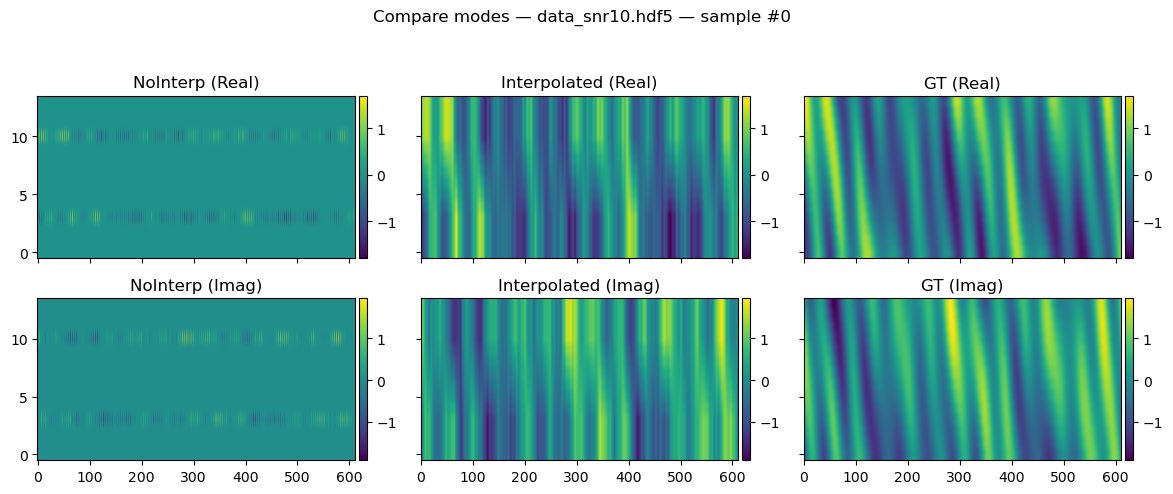

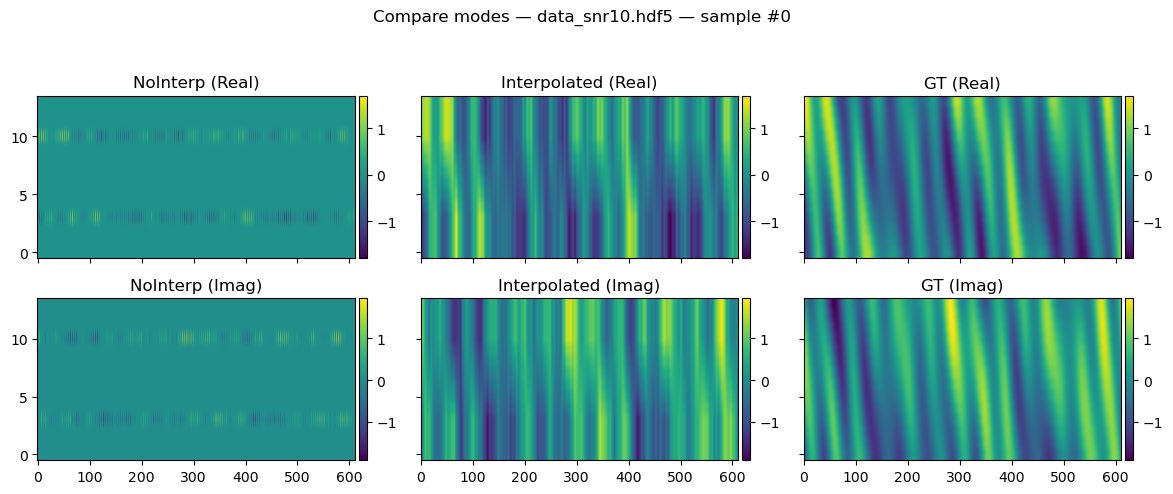

In [2]:
root_dir = "/home/rghasemi/Wireless_communication/MD_datexperiment_SISO/NlOS_updated/ps2_p153/speed15/p_spacing4"
compare_nointerp_vs_interp(root_dir, key_substr="snr10", idx=0, save_path=None)
root_dir = "/home/rghasemi/Wireless_communication/MD_datexperiment_SISO/lOS_updated/ps2_p153/speed15/p_spacing4"
compare_nointerp_vs_interp(root_dir, key_substr="snr10", idx=0, save_path=None)


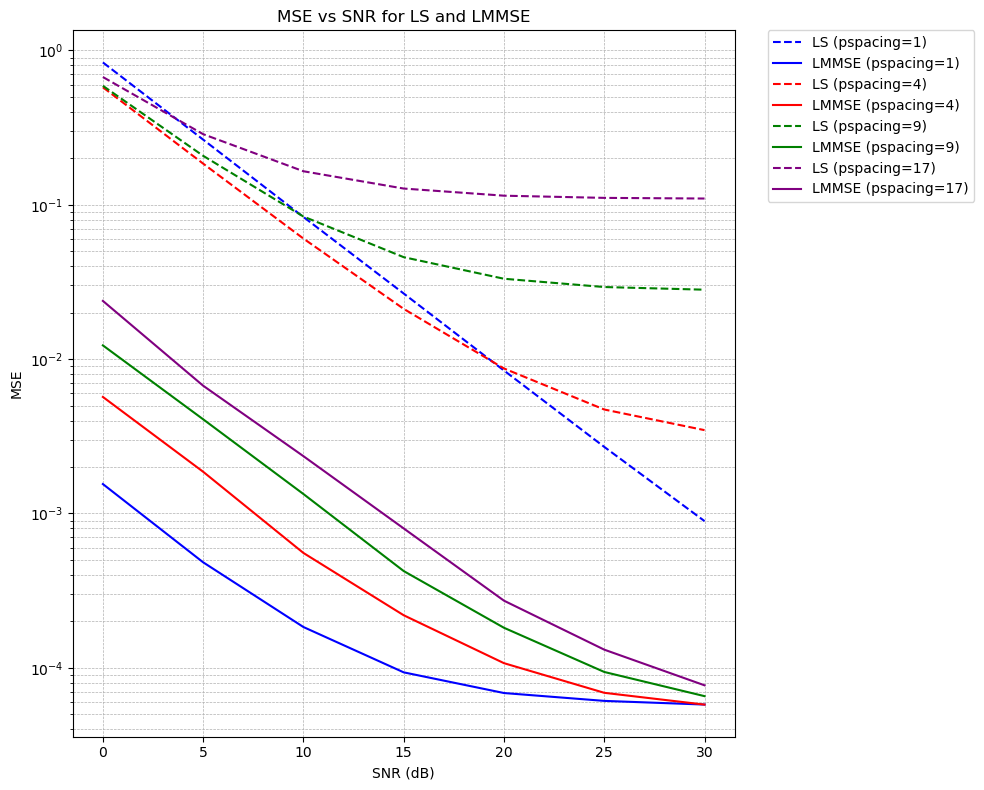

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mse_vs_snr(csv_files, pspacings):
    """
    csv_files: list of file paths to CSV files
    pspacings: list of pspacing values corresponding to each CSV file
    """
    # Define colors for different pspacings
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    plt.figure(figsize=(10, 8))
    
    for i, (file, p) in enumerate(zip(csv_files, pspacings)):
        # Load CSV
        df = pd.read_csv(file)
        
        # Pick color based on index
        color = colors[i % len(colors)]
        
        # Plot LS (dashed) and LMMSE (solid) with same color
        plt.plot(df["SNR_dB"], df["LS"], linestyle="--", color=color, 
                 label=f"LS (pspacing={p})")
        plt.plot(df["SNR_dB"], df["LMMSE"], linestyle="-", color=color, 
                 label=f"LMMSE (pspacing={p})")
    
    # Labels and formatting
    plt.xlabel("SNR (dB)")
    plt.ylabel("MSE")
    plt.yscale("log")  # Often MSE is plotted on log scale
    plt.title("MSE vs SNR for LS and LMMSE")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.show()


# Example usage:
csv_files = [
    "/home/rghasemi/Wireless_communication/plots_by_channel_debug/umi_interp/5shot/data_snr5.hdf5/mse_vs_snr.csv",
    "/home/rghasemi/Wireless_communication/plots_by_channel_pspacing_4/umi_interp/5shot/data_snr5.hdf5/mse_vs_snr.csv",
    "/home/rghasemi/Wireless_communication/plots_by_channel_pspacing_9/umi_interp/5shot/data_snr5.hdf5/mse_vs_snr.csv",
    "/home/rghasemi/Wireless_communication/plots_by_channel_pspacing_17/umi_interp/5shot/data_snr5.hdf5/mse_vs_snr.csv"
]
pspacings = [1, 4, 9, 17]

plot_mse_vs_snr(csv_files, pspacings)
